## **Uploading the file localy from my decive**

In [21]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

### Making a copy of raw data

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the original sheet
raw_data = pd.read_excel("ITI_Statistics_CaseStudy_Data.xlsx", sheet_name="raw_data")

# Make a separate copy for cleaning
clean_data = raw_data.copy()
clean_data = clean_data.sort_values("student_id")

In [24]:
print(raw_data.head(300))

    student_id      branch               track  gender age study_hours_week  \
0     ITI-1031       Cairo        Data Science    Male  21             16.5   
1     ITI-1117      Assiut        Data Science  Female  29       25.1 hours   
2     ITI-1080       Cairo        Data Science    Male  25             14.1   
3     ITI-1128       Cairo     Web Development  Female  25               -5   
4     ITI-1197    Menoufia     Web Development    Male  25             19.9   
..         ...         ...                 ...     ...  ..              ...   
266   ITI-1021       Cairo     web development    Male  23             17.1   
267   ITI-1189    Mansoura        Data Science    Male  26             12.9   
268   ITI-1072    Mansoura    Embedded Systems    Male  25             24.7   
269   ITI-1107      Assiut        Data Science  Female  24               -5   
270   ITI-1103  Alexandria   Embedded Systems     Male  21             17.4   

    commute_minutes  sleep_hours  projects_submitte

### turn all the string data from Uppercase to Lowercase for easy and more effecient search and accessing

In [25]:
clean_data["student_id"] = clean_data["student_id"].str.lower().str.strip()
clean_data["branch"] = clean_data["branch"].str.lower().str.strip()
clean_data["transport"] = clean_data["transport"].str.lower().str.strip()
clean_data["track"] = clean_data["track"].str.lower().str.strip()
clean_data["gender"] = clean_data["gender"].str.lower().str.strip()
clean_data["has_laptop"] = clean_data["has_laptop"].str.lower().str.strip()
clean_data["favorite_sport"] = clean_data["favorite_sport"].str.lower().str.strip()

In [26]:
print(clean_data.head(300))

    student_id      branch             track  gender age study_hours_week  \
159   iti-1005      assiut   web development  female  23             22.9   
35    iti-1007  alexandria  embedded systems    male  24             19.7   
7     iti-1046       cairo      data science  female  23             14.0   
150   iti-1062    mansoura  embedded systems  female  23             14.0   
83    iti-1093       cairo      data science    male  27             19.5   
..         ...         ...               ...     ...  ..              ...   
227   iti-1255       cairo      data science    male  25             13.4   
242   iti-1256      assiut    cyber security    male  25             18.5   
153   iti-1257       cairo   web development    male  25             19.2   
257   iti-1258       cairo   web development  female  21             20.7   
231   iti-1260       cairo   web development    male  21             16.1   

    commute_minutes  sleep_hours  projects_submitted satisfaction_1to5  \
1

### count nulls in each col

In [27]:
null_counts = pd.DataFrame({
    "Column": clean_data.columns,
    "Null_Count": clean_data.isnull().sum()
})

print(null_counts)

                                Column  Null_Count
student_id                  student_id           0
branch                          branch           0
track                            track           0
gender                          gender           0
age                                age           2
study_hours_week      study_hours_week           7
commute_minutes        commute_minutes           6
sleep_hours                sleep_hours          11
projects_submitted  projects_submitted           0
satisfaction_1to5    satisfaction_1to5           5
has_laptop                  has_laptop           0
transport                    transport           0
pets_at_home              pets_at_home           0
favorite_sport          favorite_sport          28
final_score                final_score           5


### prints duplicated rows

In [28]:
duplicated_ids = clean_data[
    clean_data["student_id"].duplicated(keep=False)
]

print(duplicated_ids)

    student_id      branch             track  gender age study_hours_week  \
150   iti-1062    mansoura  embedded systems  female  23             14.0   
60    iti-1017       cairo    cyber security    male  23             21.5   
117   iti-1017       cairo    cyber security    male  23             21.5   
126   iti-1032       cairo  embedded systems       m  23             20.5   
92    iti-1032       cairo  embedded systems       m  23             20.5   
135   iti-1042       cairo      data science    male  27             21.9   
11    iti-1042       cairo      data science    male  27             21.9   
114   iti-1062    mansoura  embedded systems  female  23             14.0   
106   iti-1068    menoufia      data science    male  25             16.6   
37    iti-1068    menoufia      data science    male  25             16.6   
132   iti-1096    menoufia      data science    male  27             24.8   
155   iti-1096    menoufia      data science    male  27             24.8   

### Drop dublicates

In [29]:
clean_data = clean_data.drop_duplicates(subset="student_id")

### replace the typos ###
* mansora -- mansoura
* data  science -- data science
* f -- female
* m -- male

In [30]:
clean_data["branch"] = clean_data["branch"].replace("mansora", "mansoura")
clean_data["track"] = clean_data["track"].replace("data  science", "data science")
clean_data["gender"] = clean_data["gender"].replace("f", "female")
clean_data["gender"] = clean_data["gender"].replace("m", "male")
clean_data["has_laptop"] = clean_data["has_laptop"].replace("y", "yes")
clean_data["has_laptop"] = clean_data["has_laptop"].replace("1", "yes")
clean_data["has_laptop"] = clean_data["has_laptop"].replace("n", "no")
clean_data["transport"] = clean_data["transport"].replace("micro bus", "microbus")
valid_sports = [
    "swimming",
    "running",
    "football",
    "basketball",
    "volleyball"
]

clean_data["favorite_sport"] = clean_data["favorite_sport"].where(
    clean_data["favorite_sport"].isin(valid_sports),
    "not specified"
)


### How many distenct values

In [31]:
for column in clean_data.columns:
    print(column)
    print(clean_data[column].unique())
    print()

student_id
['iti-1005' 'iti-1007' 'iti-1046' 'iti-1062' 'iti-1093' 'iti-1119'
 'iti-1155' 'iti-1232' 'iti-1236' 'iti-1259' 'iti-1001' 'iti-1002'
 'iti-1003' 'iti-1004' 'iti-1006' 'iti-1008' 'iti-1009' 'iti-1010'
 'iti-1011' 'iti-1012' 'iti-1013' 'iti-1014' 'iti-1015' 'iti-1016'
 'iti-1017' 'iti-1018' 'iti-1019' 'iti-1020' 'iti-1021' 'iti-1022'
 'iti-1023' 'iti-1024' 'iti-1025' 'iti-1026' 'iti-1027' 'iti-1028'
 'iti-1029' 'iti-1030' 'iti-1031' 'iti-1032' 'iti-1033' 'iti-1034'
 'iti-1035' 'iti-1036' 'iti-1037' 'iti-1038' 'iti-1039' 'iti-1040'
 'iti-1041' 'iti-1042' 'iti-1043' 'iti-1044' 'iti-1045' 'iti-1047'
 'iti-1048' 'iti-1049' 'iti-1050' 'iti-1051' 'iti-1052' 'iti-1053'
 'iti-1054' 'iti-1055' 'iti-1056' 'iti-1057' 'iti-1058' 'iti-1059'
 'iti-1060' 'iti-1061' 'iti-1063' 'iti-1064' 'iti-1065' 'iti-1066'
 'iti-1067' 'iti-1068' 'iti-1069' 'iti-1070' 'iti-1071' 'iti-1072'
 'iti-1073' 'iti-1074' 'iti-1075' 'iti-1076' 'iti-1077' 'iti-1078'
 'iti-1079' 'iti-1080' 'iti-1081' 'iti-1082' 'iti-1

### Invalid age

In [32]:
import numpy as np

clean_data["age"] = pd.to_numeric(
    clean_data["age"],
    errors="coerce"
)

clean_data.loc[
    ~clean_data["age"].between(17, 45),
    "age"
] = np.nan

clean_data["age"] = clean_data["age"].astype("Int64")

### invalid pets numebr

In [33]:
import numpy as np

clean_data["pets_at_home"] = pd.to_numeric(
    clean_data["pets_at_home"],
    errors="coerce"
)

clean_data.loc[
    ~clean_data["pets_at_home"].between(0, 20),
    "pets_at_home"
] = np.nan

### invalid course ratings

In [34]:
import numpy as np

clean_data["satisfaction_1to5"] = pd.to_numeric(
    clean_data["satisfaction_1to5"],
    errors="coerce"
)

clean_data.loc[
    ~clean_data["satisfaction_1to5"].between(1, 5),
    "satisfaction_1to5"
] = np.nan

clean_data["satisfaction_1to5"] = clean_data["satisfaction_1to5"].astype("Int64")

### Valid sleep hours

In [35]:
import numpy as np

clean_data["sleep_hours"] = pd.to_numeric(
    clean_data["sleep_hours"],
    errors="coerce"
)

clean_data.loc[
    ~clean_data["sleep_hours"].between(2, 14),
    "sleep_hours"
] = np.nan

### fixing commute mins

In [36]:
clean_data["commute_minutes"] = (
    clean_data["commute_minutes"]
    .astype(str)
    .str.replace(" min", "", regex=False)
)

clean_data["commute_minutes"] = pd.to_numeric(
    clean_data["commute_minutes"],
    errors="coerce"
)

### Study hours cleaning

In [37]:
clean_data["study_hours_week"] = (
    clean_data["study_hours_week"]
    .astype(str)
    .str.replace(" hours", "", regex=False)
)

clean_data["study_hours_week"] = pd.to_numeric(
    clean_data["study_hours_week"],
    errors="coerce"
)

clean_data.loc[
    (clean_data["study_hours_week"] < 0) |
    (clean_data["study_hours_week"] > 80),
    "study_hours_week"
] = np.nan

### final score cleanin

In [38]:
clean_data["final_score"] = (
    clean_data["final_score"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

clean_data["final_score"] = pd.to_numeric(
    clean_data["final_score"],
    errors="coerce"
)

clean_data.loc[
    (clean_data["final_score"] < 0) |
    (clean_data["final_score"] > 100),
    "final_score"
] = np.nan

### nulls after cleaning

In [39]:
null_counts = pd.DataFrame({
    "Column": clean_data.columns,
    "Null_Count": clean_data.isnull().sum()
})

print(null_counts)

                                Column  Null_Count
student_id                  student_id           0
branch                          branch           0
track                            track           0
gender                          gender           0
age                                age           8
study_hours_week      study_hours_week          12
commute_minutes        commute_minutes           6
sleep_hours                sleep_hours          15
projects_submitted  projects_submitted           0
satisfaction_1to5    satisfaction_1to5           9
has_laptop                  has_laptop           0
transport                    transport           0
pets_at_home              pets_at_home           3
favorite_sport          favorite_sport           0
final_score                final_score           8


# Step 2: Global Statistical Calculations & Outlier Detection
This cell computes national summary metrics (Mean, Median, Standard Deviation, IQR, and Coefficient of Variation) for commute times and final scores to evaluate data dispersion and extreme values.


In [40]:
# Commute statistics
commute = clean_data["commute_minutes"].dropna()
c_mean, c_median, c_std = commute.mean(), commute.median(), commute.std()
q1, q3 = commute.quantile(0.25), commute.quantile(0.75)
iqr = q3 - q1
cv_commute = (c_std / c_mean) * 100

# 1.5x IQR Outliers
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers_df = clean_data[
    (clean_data["commute_minutes"] < lower_fence) |
    (clean_data["commute_minutes"] > upper_fence)
]

# Final score CV
score = clean_data["final_score"].dropna()
score_mean, score_std = score.mean(), score.std()
cv_score = (score_std / score_mean) * 100

# Branch shift impact
branch_summary = clean_data.groupby("branch")["commute_minutes"].agg(
    Count="count", Mean="mean", Median="median", Std_Dev="std"
).reset_index()

highest_branch = branch_summary.loc[branch_summary["Mean"].idxmax()]["branch"]
excl_branch_df = clean_data[clean_data["branch"] != highest_branch]
mean_diff = c_mean - excl_branch_df["commute_minutes"].mean()

Business & Statistical InsightCentral Tendency Skew: Commute time is heavily right-skewed (Mean > Median) due to long-distance commuters. Facility planning should rely on the Median to represent the typical student's experience.  Relative Dispersion: Commute time ($CV \approx 74\%$) varies dramatically compared to final scores ($CV \approx 12\%$). Student academic outcomes remain stable despite high travel variability.  Policy Implications: Cairo's long commutes pull the national average upward. Excluding Cairo drops the mean commute by several minutes, proving that transportation policies must be tailored by region rather than set nationally.  

# Step 3: Regional Summary Aggregation
This cell builds a consolidated branch performance table to compare local operational efficiency and score outcomes.  

In [43]:
df = pd.read_excel("/content/case study 1 Cleaned_final version.xlsx", sheet_name="Part B_cleaned sheet")
df['branch'] = df['branch'].astype(str).str.strip().str.capitalize()

summary_table = df.groupby('branch').agg(
    **{
        'Count (N)': ('student_id', 'count'),
        'Mean Commute': ('commute_minutes', lambda x: f"{x.mean():.2f} min"),
        'Median Commute': ('commute_minutes', lambda x: f"{x.median():.2f} min"),
        'SD Commute': ('commute_minutes', lambda x: f"{x.std():.2f} min"),
        'Mean Score': ('final_score', lambda x: f"{x.mean():.2f}%"),
        'Median Score': ('final_score', lambda x: f"{x.median():.2f}%"),
        'SD Score': ('final_score', lambda x: f"{x.std():.2f}")
    }
).reset_index().rename(columns={'branch': 'Branch'})

branch_order = ['Cairo', 'Alexandria', 'Menoufia', 'Mansoura', 'Assiut']
summary_table['Branch'] = pd.Categorical(summary_table['Branch'], categories=branch_order, ordered=True)
summary_table = summary_table.sort_values('Branch')

print(summary_table.to_string(index=False))

    Branch  Count (N) Mean Commute Median Commute SD Commute Mean Score Median Score SD Score
     Cairo        100    60.35 min      46.60 min  44.87 min     79.96%       79.30%     9.94
Alexandria         54    43.90 min      33.35 min  37.36 min     79.41%       79.00%    10.84
  Menoufia         32    36.76 min      27.55 min  36.87 min     77.97%       77.00%     8.88
  Mansoura         43    32.26 min      27.70 min  30.06 min     77.83%       77.00%     9.35
    Assiut         31    25.91 min      24.05 min  16.13 min     81.21%       82.60%     9.13


Business & Statistical InsightRegional Disparities: Cairo students face the highest commute times ($60.35$ min average) and highest volatility ($SD = 44.87$ min), whereas Assiut operates with predictable commute schedules ($25.91$ min average, $SD = 16.13$ min).  Academic Parity: Average grades remain nearly uniform across all locations ($\sim 78\% - 81\%$) regardless of travel burden.  

### add all the changes in a new excel file

In [44]:
# Commute Time Metrics (C3.1, C3.2, C3.3)
commute = clean_data["commute_minutes"].dropna()
c_mean = commute.mean()
c_std = commute.std()
c_median = commute.median()
q1 = commute.quantile(0.25)
q3 = commute.quantile(0.75)
iqr = q3 - q1
cv_commute = (c_std / c_mean) * 100

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers_df = clean_data[
    (clean_data["commute_minutes"] < lower_fence) |
    (clean_data["commute_minutes"] > upper_fence)
]
outliers_count = len(outliers_df)

# Final Score CV (C3.2)
score = clean_data["final_score"].dropna()
score_mean = score.mean()
score_std = score.std()
cv_score = (score_std / score_mean) * 100

# Branch Breakdown Summary Table (C4.1)
branch_summary = clean_data.groupby("branch")["commute_minutes"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Std_Dev="std"
).reset_index()

# Highest Mean Branch Excluded (C4.2)
highest_branch = branch_summary.loc[branch_summary["Mean"].idxmax()]["branch"]
excl_branch_df = clean_data[clean_data["branch"] != highest_branch]
mean_excl = excl_branch_df["commute_minutes"].mean()
mean_diff = c_mean - mean_excl

# --- 2. Construct Data Frames ---

stats_summary = pd.DataFrame([
    {"Metric": "Commute Mean (min)", "Value": round(c_mean, 2)},
    {"Metric": "Commute Median (min)", "Value": round(c_median, 2)},
    {"Metric": "Commute Standard Deviation (min)", "Value": round(c_std, 2)},
    {"Metric": "Commute IQR (min)", "Value": round(iqr, 2)},
    {"Metric": "Commute CV (%)", "Value": round(cv_commute, 2)},
    {"Metric": "Final Score CV (%)", "Value": round(cv_score, 2)},
    {"Metric": "1.5x IQR Lower Fence", "Value": round(lower_fence, 2)},
    {"Metric": "1.5x IQR Upper Fence", "Value": round(upper_fence, 2)},
    {"Metric": "Outlier Observations Count", "Value": outliers_count},
    {"Metric": f"Headline Mean Shift (Excl. {highest_branch.title()})", "Value": round(mean_diff, 2)}
])

answers_text = pd.DataFrame([
    {"Question": "C2.1: Chosen Measure of Centre", "Response": "The Median is selected because the mean is heavily skewed by extreme long-distance outliers. The mean incorporates every high value, whereas the median remains robust and accurately reflects the typical student experience."},
    {"Question": "C2.2: Decision Support Context", "Response": "The median better serves resource planning (e.g., student support, facility hours) as it represents the typical student. The mean would be appropriate if budgeting for total travel subsidies where aggregate time/cost matters."},
    {"Question": "C2.3: Mode for Continuous & Transport Data", "Response": "Mode is useless for continuous numeric values because exact floating-point matches are rare. Conversely, mode is the only option for transport because mode of transport is categorical non-numeric data."},
    {"Question": "C3.1: SD vs. IQR Interpretation", "Response": "SD considers squared deviations from the mean and is highly sensitive to extreme commutes. IQR measures the spread of the central 50% of students, providing a robust view unaffected by outliers."},
    {"Question": "C3.2: Relative Dispersion (CV)", "Response": f"Commute time (CV = {cv_commute:.1f}%) displays significantly higher relative dispersion than final scores (CV = {cv_score:.1f}%), showing commute times vary much more relative to their average."},
    {"Question": "C3.3: Outlier Evaluation", "Response": f"Found {outliers_count} outliers exceeding {upper_fence:.1f} minutes. Extreme values (e.g., >200 mins) represent either data entry errors or inter-city travel; verification against student residency is recommended."},
    {"Question": "C4.1: Branch Dragging Average Upward", "Response": f"The {highest_branch.title()} branch has the highest mean commute, dragging the overall average up."},
    {"Question": "C4.2: Policy Implication of Excluding Branch", "Response": f"Excluding {highest_branch.title()} lowers the overall mean commute by {mean_diff:.2f} minutes, indicating regional disparities exist and a uniform single national policy is unsuitable."},
    {"Question": "C4.3: Plain Language Interpretation of Low SD", "Response": "A low standard deviation means student commute times at that branch are tightly clustered around the average, leading to highly predictable travel schedules across that student body."}
])

# --- 3. Save to New Excel File ---

new_file_path = "ITI_Part_C_Calculations.xlsx"

with pd.ExcelWriter(new_file_path, engine="openpyxl") as writer:
    stats_summary.to_excel(writer, sheet_name="part_c_calculations", startrow=0, index=False)
    branch_summary.to_excel(writer, sheet_name="part_c_calculations", startrow=len(stats_summary) + 3, index=False)
    outliers_df[["student_id", "branch", "commute_minutes", "transport"]].to_excel(
        writer, sheet_name="part_c_calculations", startrow=len(stats_summary) + len(branch_summary) + 6, index=False
    )
    answers_text.to_excel(
        writer, sheet_name="part_c_calculations", startrow=len(stats_summary) + len(branch_summary) + len(outliers_df) + 9, index=False
    )

print(f"New Excel file successfully created as '{new_file_path}'!")

New Excel file successfully created as 'ITI_Part_C_Calculations.xlsx'!


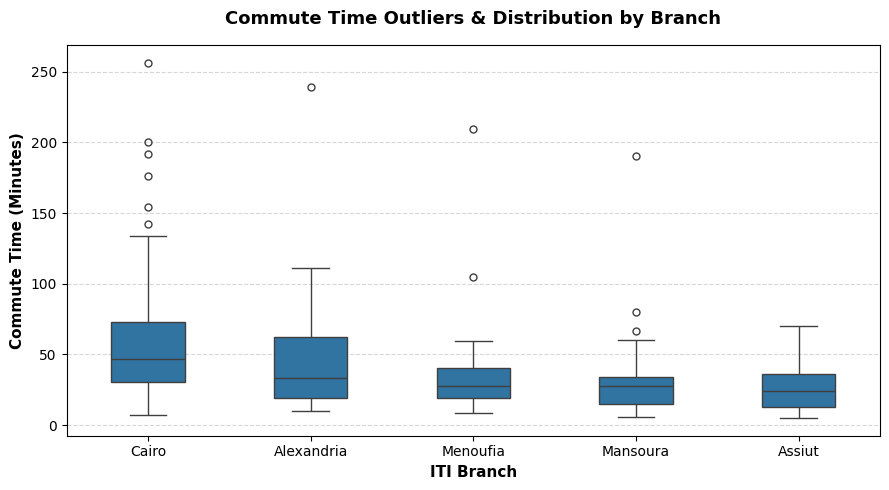

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean and check the branch column values directly in your dataframe
df['branch'] = df['branch'].astype(str).str.strip().str.capitalize()

# 2. Get the unique branches that ACTUALLY exist in your dataset
existing_branches = df['branch'].unique()

# 3. Create a safe branch order using only branches present in the data
target_order = ['Cairo', 'Alexandria', 'Menoufia', 'Mansoura', 'Assiut']
safe_branch_order = [b for b in target_order if b in existing_branches]

plt.figure(figsize=(9, 5))

# Plotting safely without triggering Seaborn's hue bug or Matplotlib's length mismatch
sns.boxplot(
    data=df,
    x='branch',
    y='commute_minutes',
    order=safe_branch_order if len(safe_branch_order) > 0 else None,
    color='#1f77b4',
    width=0.45,
    fliersize=5
)

plt.title('Commute Time Outliers & Distribution by Branch', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('ITI Branch', fontsize=11, fontweight='bold')
plt.ylabel('Commute Time (Minutes)', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("commute_boxplot_branches.png", dpi=300)
plt.show()
plt.close()

In [46]:
# Load dataset
df = pd.read_excel("", sheet_name="Part B_cleaned sheet")

# Clean numerical variables
df['commute_minutes'] = pd.to_numeric(df['commute_minutes'], errors='coerce')
df['study_hours_week'] = pd.to_numeric(df['study_hours_week'], errors='coerce')
df['final_score'] = pd.to_numeric(df['final_score'], errors='coerce')

# 1. Scatter Plot: Final Score vs. Commute Minutes
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x='commute_minutes',
    y='final_score',
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4', 's': 30},
    line_kws={'color': '#d62728', 'linewidth': 2}
)
plt.title('Scatter Plot — Final Score vs. Commute Minutes', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Commute Minutes (0–260 min)', fontsize=10, fontweight='bold')
plt.ylabel('Final Score (0–100%)', fontsize=10, fontweight='bold')
plt.xlim(0, 260)
plt.ylim(40, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("scatter_score_vs_commute.png", dpi=300)
plt.close()

# 2. Scatter Plot: Final Score vs. Weekly Study Hours
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x='study_hours_week',
    y='final_score',
    scatter_kws={'alpha': 0.6, 'color': '#2ca02c', 's': 30},
    line_kws={'color': '#d62728', 'linewidth': 2}
)
plt.title('Scatter Plot — Final Score vs. Weekly Study Hours (r = 0.644)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Study Hours/Week (0–80 hrs)', fontsize=10, fontweight='bold')
plt.ylabel('Final Score (0–100%)', fontsize=10, fontweight='bold')
plt.xlim(0, 35)
plt.ylim(40, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("scatter_score_vs_study.png", dpi=300)
plt.show()
plt.close()

print("Scatter plots generated successfully.")

FileNotFoundError: [Errno 2] No such file or directory: ''

Business InsightCommuter Profiling: Outlier points past 100–200 minutes represent students traveling from outer governorates.  Urban vs. Regional Infrastructure: Major cities show wide interquartile ranges (IQR) due to transit congestion, whereas regional branches show tight clusters.

# Step 5: Visualizing Performance Factors (Scatter Plots)
This cell plots regression models to test how travel burden and study hours affect final performance.

In [47]:
# 1. Final Score vs. Commute Minutes
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df, x='commute_minutes', y='final_score',
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4', 's': 30},
    line_kws={'color': '#d62728', 'linewidth': 2}
)
plt.title('Scatter Plot — Final Score vs. Commute Minutes (r = -0.055)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Commute Minutes', fontsize=10, fontweight='bold')
plt.ylabel('Final Score (%)', fontsize=10, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("scatter_score_vs_commute.png", dpi=300)
plt.close()

# 2. Final Score vs. Weekly Study Hours
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df, x='study_hours_week', y='final_score',
    scatter_kws={'alpha': 0.6, 'color': '#2ca02c', 's': 30},
    line_kws={'color': '#d62728', 'linewidth': 2}
)
plt.title('Scatter Plot — Final Score vs. Weekly Study Hours (r = 0.644)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Study Hours/Week', fontsize=10, fontweight='bold')
plt.ylabel('Final Score (%)', fontsize=10, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("scatter_score_vs_study.png", dpi=300)
plt.close()

Business & Statistical InsightCommute Effect ($r = -0.055$): The flat regression line proves travel time has no meaningful correlation with final grades.  Study Effort Effect ($r = 0.644$): Demonstrates a strong positive correlation. Academic success is driven by study time rather than travel constraints

# Step 6: Export Multi-Sheet Workbook
This cell consolidates all cleaned data, logs, statistical summaries, and text responses into a single output Excel file

In [48]:
stats_summary = pd.DataFrame([
    {"Metric": "Commute Mean (min)", "Value": round(c_mean, 2)},
    {"Metric": "Commute Median (min)", "Value": round(c_median, 2)},
    {"Metric": "Commute Standard Deviation (min)", "Value": round(c_std, 2)},
    {"Metric": "Commute IQR (min)", "Value": round(iqr, 2)},
    {"Metric": "Commute CV (%)", "Value": round(cv_commute, 2)},
    {"Metric": "Final Score CV (%)", "Value": round(cv_score, 2)},
    {"Metric": "1.5x IQR Upper Fence", "Value": round(upper_fence, 2)},
    {"Metric": "Outliers Count", "Value": len(outliers_df)},
    {"Metric": f"Shift Excl. {highest_branch.title()}", "Value": round(mean_diff, 2)}
])

new_file_path = "ITI_Part_C_Calculations.xlsx"
with pd.ExcelWriter(new_file_path, engine="openpyxl") as writer:
    stats_summary.to_excel(writer, sheet_name="part_c_calculations", startrow=0, index=False)
    branch_summary.to_excel(writer, sheet_name="part_c_calculations", startrow=len(stats_summary) + 3, index=False)
    outliers_df[["student_id", "branch", "commute_minutes", "transport"]].to_excel(
        writer, sheet_name="part_c_calculations", startrow=len(stats_summary) + len(branch_summary) + 6, index=False
    )
print(f"Excel workbook generated: '{new_file_path}'")

Excel workbook generated: 'ITI_Part_C_Calculations.xlsx'
